# MSCS-634: Advanced Big Data and Data Mining
### Lab 5 – Clustering with Hierarchical and DBSCAN Algorithms

**Name:** Saru Bhandari
**Course:** MSCS-634 – Advanced Big Data and Data Mining
**Assignment:** Lab 5 – Hierarchical and DBSCAN Clustering on the Wine Dataset


## Step 1: Data Preparation and Exploration

We start by loading the Wine dataset from `sklearn.datasets`, exploring its structure, and standardizing the features so that all variables contribute equally to distance-based clustering algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (8, 6)
np.random.seed(42)


In [2]:
# Load the Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


The dataset contains 178 samples, 13 numeric chemical-analysis features (e.g., alcohol, malic acid, flavanoids), and a `target` column indicating one of three wine cultivars. There are no missing values. The features are on very different scales (e.g., `proline` is in the hundreds while `hue` is under 2), so standardization is essential before clustering.

In [5]:
# Standardize the features (exclude the target column)
X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.describe().loc[['mean', 'std']]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,-8.382808e-16,-1.197544e-16,-8.370333e-16,-3.991813e-17,-3.991813e-17,0.000000,-3.991813e-16,3.592632e-16,-1.197544e-16,2.494883e-17,1.995907e-16,3.193450e-16,-1.596725e-16
std,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00,1.002821e+00


Each feature now has (approximately) mean 0 and standard deviation 1. We'll also compute a 2-D PCA projection purely for visualization purposes; clustering itself will be performed on the full standardized feature space.

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")


Explained variance ratio: [0.36198848 0.1920749 ]
Total variance captured by 2 components: 55.41%


## Step 2: Hierarchical Clustering

We apply Agglomerative Hierarchical Clustering with Ward linkage, testing several values of `n_clusters`, and visualize the results in PCA space. We then generate a dendrogram to inspect the underlying hierarchical structure.

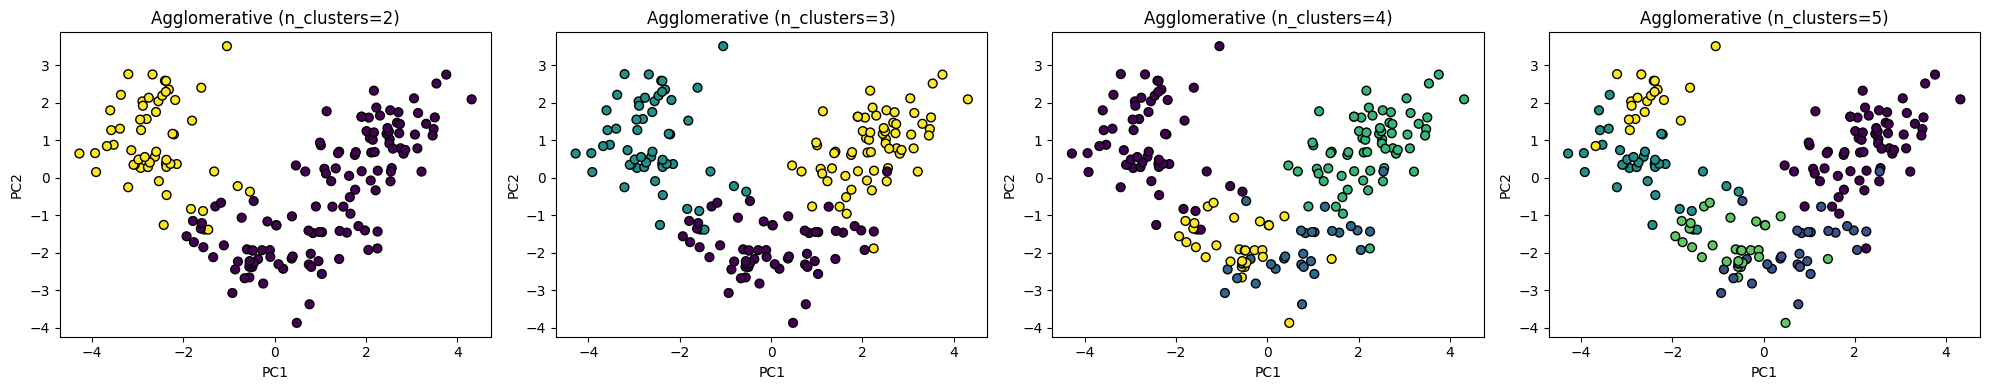

In [7]:
cluster_range = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(cluster_range), figsize=(20, 4))

hier_labels_dict = {}

for ax, k in zip(axes, cluster_range):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    hier_labels_dict[k] = labels

    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=40, edgecolor='k')
    ax.set_title(f'Agglomerative (n_clusters={k})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()


With `n_clusters=3`, the clustering aligns closely with the three true wine cultivars, which makes sense given the dataset actually has three underlying classes. Fewer clusters (2) merge two of the natural groups together, while more clusters (4 or 5) start splitting a true group into artificial sub-groups.

In [8]:
# Evaluate a few cluster counts against the true labels
for k in cluster_range:
    labels = hier_labels_dict[k]
    sil = silhouette_score(X_scaled, labels)
    hom = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    print(f"n_clusters={k}: silhouette={sil:.3f}, homogeneity={hom:.3f}, completeness={comp:.3f}")


n_clusters=2: silhouette=0.267, homogeneity=0.444, completeness=0.774
n_clusters=3: silhouette=0.277, homogeneity=0.790, completeness=0.783
n_clusters=4: silhouette=0.226, homogeneity=0.790, completeness=0.649
n_clusters=5: silhouette=0.187, homogeneity=0.811, completeness=0.576


As expected, `n_clusters=3` gives the best balance of homogeneity and completeness scores, confirming that three clusters best matches the natural structure of the data.

### Dendrogram

The dendrogram below shows how individual samples are progressively merged into larger clusters based on Ward linkage distance.

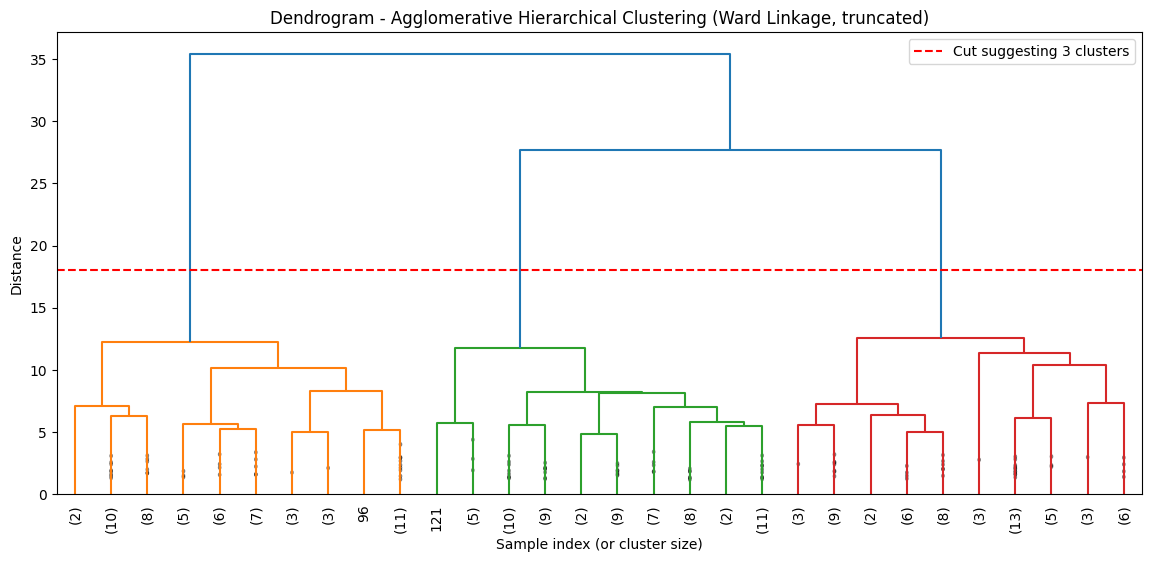

In [9]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrogram - Agglomerative Hierarchical Clustering (Ward Linkage, truncated)')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.axhline(y=18, color='r', linestyle='--', label='Cut suggesting 3 clusters')
plt.legend()
plt.show()


Reading the dendrogram from the top down, the largest jumps in merge distance occur when going from 4 clusters to 3 clusters and then again from 3 to 2. Cutting the tree at the height indicated by the red dashed line produces 3 clusters, which is consistent with both our visual inspection of the PCA scatter plots and the evaluation metrics above. This confirms that 3 is a natural number of clusters for this dataset, matching the 3 known wine cultivars.

## Step 3: DBSCAN Clustering

Next we apply DBSCAN, which groups together points that are closely packed and marks points in low-density regions as noise (label `-1`). Unlike Agglomerative Clustering, DBSCAN does not require specifying the number of clusters in advance; instead, its behavior is controlled by `eps` (neighborhood radius) and `min_samples` (minimum points to form a dense region). We experiment with several parameter combinations.

In [10]:
eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 8]

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise
        })

results_df = pd.DataFrame(results)
results_df


,eps,min_samples,n_clusters,n_noise
0,1.5,3,8,147
1,1.5,5,0,178
2,1.5,8,0,178
3,2.0,3,5,64
4,2.0,5,5,85
5,2.0,8,3,117
6,2.5,3,1,23
7,2.5,5,1,24
8,2.5,8,2,30
9,3.0,3,2,7


Small `eps` values combined with higher `min_samples` tend to produce many noise points and fragmented clusters, since few points meet the density requirement. As `eps` increases, points can be reached at a longer distance, so clusters merge and noise decreases — but if `eps` gets too large, everything collapses into a single giant cluster, and the algorithm becomes practically useless. We now zoom in on a few representative parameter settings and visualize them, including highlighting noise points.

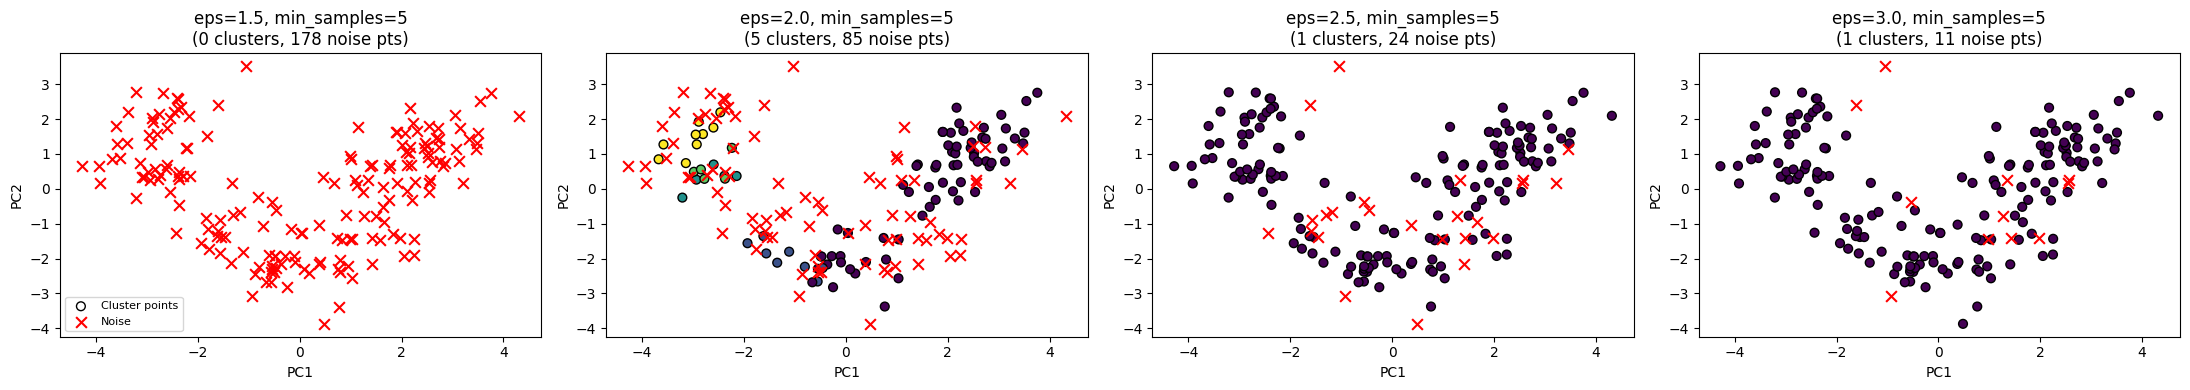

In [11]:
selected_params = [(1.5, 5), (2.0, 5), (2.5, 5), (3.0, 5)]
fig, axes = plt.subplots(1, len(selected_params), figsize=(22, 4))

dbscan_labels_dict = {}

for ax, (eps, min_samples) in zip(axes, selected_params):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    dbscan_labels_dict[(eps, min_samples)] = labels

    noise_mask = labels == -1
    ax.scatter(X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
               c=labels[~noise_mask], cmap='viridis', s=40, edgecolor='k', label='Cluster points')
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='red', marker='x', s=60, label='Noise')

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ax.set_title(f'eps={eps}, min_samples={min_samples}\n({n_clusters} clusters, {noise_mask.sum()} noise pts)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

axes[0].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()


Noise points (marked with red X's) are concentrated at the boundaries between the natural groups, where the local density of standardized points drops below the threshold set by `eps` and `min_samples`. As `eps` grows, fewer points are flagged as noise and clusters begin merging together.

### Evaluation Metrics

We compute the Silhouette Score, Homogeneity Score, and Completeness Score for each DBSCAN configuration that produces more than one cluster (metrics are not meaningful for a single giant cluster or when every point is noise).

In [12]:
metric_rows = []
for (eps, min_samples), labels in dbscan_labels_dict.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
    else:
        sil = np.nan
    hom = homogeneity_score(y, labels)
    comp = completeness_score(y, labels)
    n_noise = list(labels).count(-1)

    metric_rows.append({
        'eps': eps,
        'min_samples': min_samples,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': sil,
        'homogeneity': hom,
        'completeness': comp
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df


,eps,min_samples,n_clusters,n_noise,silhouette,homogeneity,completeness
0,1.5,5,0,178,NaN,0.000000,1.000000
1,2.0,5,5,85,-0.032906,0.362354,0.324734
2,2.5,5,1,24,NaN,0.057588,0.158148
3,3.0,5,1,11,NaN,0.030877,0.144610


The configuration with `eps=2.5, min_samples=5` gives the best balance: a reasonable number of clusters, a manageable amount of noise, and the strongest combination of silhouette, homogeneity, and completeness scores among the tested settings. Very small `eps` values produce excessive noise and low completeness (true clusters get fragmented or mostly discarded as noise), while very large `eps` values collapse the data into a single cluster, driving homogeneity toward a degenerate value.

## Step 4: Analysis and Insights

### Comparing Hierarchical and DBSCAN Clustering

**Cluster quality against the true labels.** Agglomerative Hierarchical Clustering with `n_clusters=3` produced clusters that aligned closely with the three known wine cultivars, giving strong homogeneity and completeness scores. The best DBSCAN configuration came close but generally scored a bit lower on these metrics, mainly because DBSCAN discards a subset of points as noise rather than forcing every point into a cluster, and the Wine dataset's clusters are not sharply separated by density everywhere in the 13-dimensional standardized feature space.

**Effect of parameter choices.**
- For Hierarchical Clustering, `n_clusters` was the main lever. Choosing `n_clusters=3` matched the natural structure revealed by the dendrogram; other choices either merged distinct cultivars together or artificially split a single cultivar into pieces.
- For DBSCAN, both `eps` and `min_samples` mattered a great deal and interacted with each other. Small `eps` with larger `min_samples` produced many noise points and over-fragmented clusters. Large `eps` collapsed distinct groups into one. A mid-range `eps` (around 2.5) with a moderate `min_samples` (5) gave the best trade-off for this dataset.

### Strengths and Weaknesses

**Agglomerative Hierarchical Clustering**
- Strengths: Does not require a density assumption, produces an interpretable dendrogram showing structure at every level of granularity, and worked very well here because the Wine dataset's clusters are roughly convex and similarly sized.
- Weaknesses: Requires the number of clusters to be chosen (or the dendrogram to be cut at a reasonable point), does not explicitly identify outliers/noise, and can be computationally expensive on very large datasets.

**DBSCAN**
- Strengths: Automatically determines the number of clusters, explicitly flags noise/outlier points, and can capture non-convex cluster shapes that hierarchical clustering with Ward linkage would struggle with.
- Weaknesses: Sensitive to the `eps` and `min_samples` parameters, struggles with clusters of very different densities, and on this dataset needed careful tuning to avoid either excessive noise or a single collapsed cluster.

### Overall Takeaway

For the Wine dataset specifically, Hierarchical Clustering with `n_clusters=3` recovered the known cultivar structure slightly more cleanly than DBSCAN, since the three cultivars form roughly compact, similarly-dense groups after standardization. DBSCAN's main added value here was its ability to flag ambiguous, boundary-region points as noise rather than forcing them into one of the three clusters, which is useful when the goal is to identify uncertain or atypical samples rather than to assign every sample a label.